<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentFacebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [3]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [4]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [5]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [6]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [7]:
fb_df = df[df["symbols"].str.contains("FB.US", na=False)].copy()

print("Broj FB.US vesti:", len(fb_df))

Broj FB.US vesti: 1912


In [ ]:
fb_df.to_csv("/content/drive/MyDrive/fb_news.csv", index=False)

In [8]:
fb_df["year"] = pd.to_datetime(fb_df["date"]).dt.year
fb_df["year"].value_counts().sort_index()

,count
year,
2018,1
2020,34
2021,1202
2022,656
2023,18
2024,1


In [9]:
random_news = fb_df.sample(1)

print("DATUM:", random_news["date"].values[0])
print("NASLOV:", random_news["title"].values[0])
print("TEKST:", random_news["content"].values[0])

DATUM: 2022-02-02T01:46:01.000000000
NASLOV: Were Hedge Funds Right About Apple Inc. (AAPL)?
TEKST: Insider Monkey has processed numerous 13F filings of hedge funds and successful value investors to create an extensive database of hedge fund holdings. The 13F filings show the hedge funds' and successful investors' positions as of the end of the third quarter. You can find articles about an individual hedge fund's trades on numerous financial news websites. However, in this article we will take a look at their collective moves over the last 6 years and analyze what the smart money thinks of Apple Inc. (NASDAQ:AAPL) based on that data and determine whether they were really smart about the stock.

Is Apple Inc. (NASDAQ:AAPL) a bargain? Money managers were getting less bullish. The number of bullish hedge fund positions fell by 18 recently. Apple Inc. (NASDAQ:AAPL) was in 120 hedge funds' portfolios at the end of September. The all time high for this statistic is 152. Our calculations also

In [10]:
!pip install yfinance

In [11]:
import yfinance as yf
import pandas as pd

In [12]:
meta_prices = yf.download("META", start="2018-01-01", end="2024-12-31")

meta_prices = meta_prices.reset_index()

meta_prices = meta_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_11464/1033626629.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  meta_prices = yf.download("META", start="2018-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [13]:
fb_df["date"] = pd.to_datetime(fb_df["date"]).dt.date
meta_prices["date"] = pd.to_datetime(meta_prices["date"]).dt.date


fb_df["date"] = pd.to_datetime(fb_df["date"])
meta_prices["date"] = pd.to_datetime(meta_prices["date"])


meta_df = fb_df.sort_values("date")
meta_prices = meta_prices.sort_values("date")


meta_prices.columns = meta_prices.columns.droplevel(1)
meta_prices = meta_prices.rename(columns={"Close": "close"})

In [14]:
import pandas as pd

# 1) priprema price tabele
meta_prices = meta_prices.sort_values("date").copy()
meta_prices["close_t"] = meta_prices["close"]
meta_prices["close_t1"] = meta_prices["close"].shift(-1)
meta_prices["open_t1"] = meta_prices["Open"].shift(-1)
meta_prices["open_t2"] = meta_prices["Open"].shift(-2)

meta_prices["avg_t"] = (
    meta_prices["Open"] +
    meta_prices["High"] +
    meta_prices["Low"] +
    meta_prices["close"]
) / 4

meta_prices["avg_t1"] = meta_prices["avg_t"].shift(-1)

# 2) merge vesti, sledeći trading dan
meta_merged = pd.merge_asof(
    fb_df.sort_values("date"),
    meta_prices[["date", "close_t", "close_t1", "open_t1", "open_t2", "avg_t", "avg_t1"]],
    on="date",
    direction="forward"
)

# 3) prinosi

# close-close: od današnjeg close do sutrašnjeg close
meta_merged["return_close_close"] = (
    meta_merged["close_t1"] - meta_merged["close_t"]
) / meta_merged["close_t"]

# open-close: od sutrašnjeg open do sutrašnjeg close
meta_merged["return_open_close"] = (
    meta_merged["close_t1"] - meta_merged["open_t1"]
) / meta_merged["open_t1"]

# open-open: od sutrašnjeg open do preksutrašnjeg open
meta_merged["return_open_open"] = (
    meta_merged["open_t2"] - meta_merged["open_t1"]
) / meta_merged["open_t1"]

# avg-avg
meta_merged["return_avg_avg"] = (
    meta_merged["avg_t1"] - meta_merged["avg_t"]
) / meta_merged["avg_t"]

In [15]:
meta_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2018-04-16,Detailed Research: Economic Perspectives on Ge...,163.546555,167.346725,0.023236,0.006332,0.017066,0.014294
1,2020-03-30,Buying What the Fed Buys,164.657852,165.501251,0.005122,-0.023326,0.007977,0.026879
2,2020-04-24,How to Invest Your Stimulus Check,188.590057,186.040070,-0.013521,-0.020762,-0.026783,0.022537
3,2020-05-13,Keep Your Virus News Away From My Ad: Brands B...,203.503006,205.199722,0.008338,0.013379,0.020981,-0.012605
4,2020-05-14,Apple Acquires Startup NextVR that Broadcasts ...,205.199722,209.238022,0.019680,0.033517,0.027330,0.017895


In [16]:
d = pd.to_datetime("2021-07-28")

meta_merged[meta_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
712,370.373505,355.529968


In [18]:
meta_merged["direction_close_close"] = meta_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

meta_merged["direction_open_open"] = meta_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

meta_merged["direction_open_close"] = meta_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

meta_merged["direction_avg_avg"] = meta_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [19]:
meta_merged["direction_close_close"].value_counts()

,count
direction_close_close,
DOWN,1041
UP,871


In [21]:
meta_merged["direction_open_close"].value_counts()

,count
direction_open_close,
DOWN,1012
UP,900


In [20]:
meta_merged["direction_open_open"].value_counts()

,count
direction_open_open,
UP,1029
DOWN,883


In [22]:
meta_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
DOWN,996
UP,916


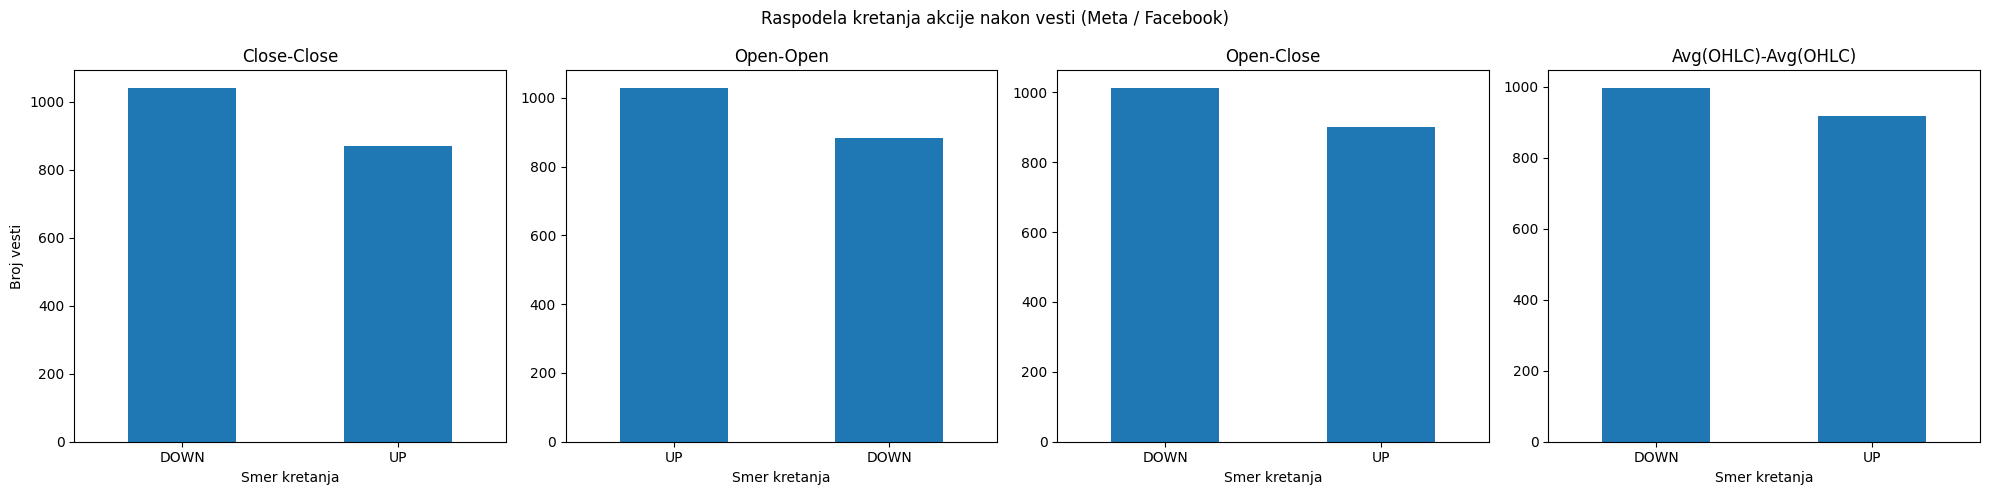

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
meta_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open (NOVO)
meta_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
meta_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
meta_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Meta / Facebook)")

plt.tight_layout()
plt.show()

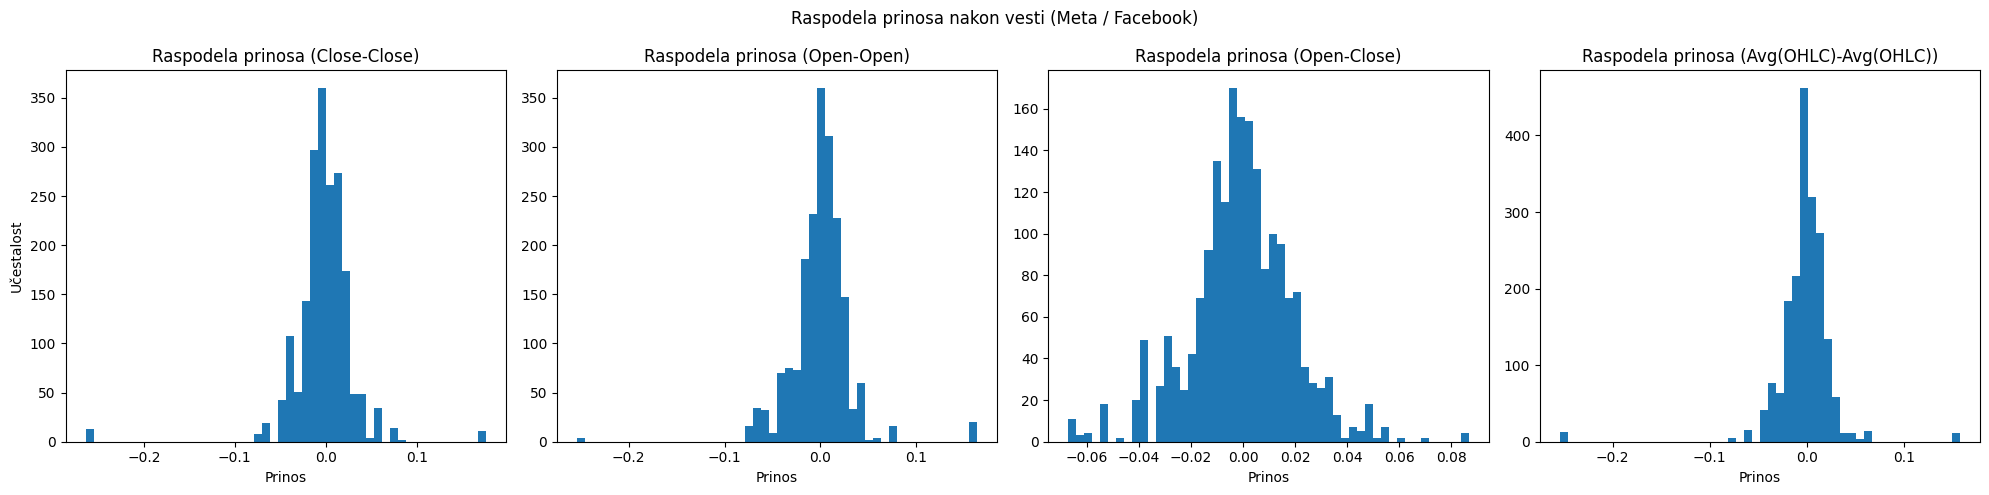

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(meta_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(meta_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(meta_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(meta_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Meta / Facebook)")

plt.tight_layout()
plt.show()

In [26]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [27]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    SOCIAL_MEDIA = "social_media_platforms"
    ADVERTISING = "digital_advertising"
    METAVERSE = "metaverse_vr_ar"
    AI = "ai_ml"
    WHATSAPP = "whatsapp_messaging"
    INSTAGRAM = "instagram_platform"
    REGULATION = "regulation_antitrust"
    LEGAL = "legal_lawsuit"
    PRIVACY = "data_privacy_security"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Meta (Facebook)-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Meta (Facebook) in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Meta (Facebook). Choose the closest single category.",
        examples=[Topic.ADVERTISING]
    )

In [28]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


meta_merged["text_for_ie"] = meta_merged.apply(combine_title_content, axis=1)

meta_merged[["text_for_ie"]].head(2)

,text_for_ie
0,TITLE: Detailed Research: Economic Perspective...
1,TITLE: Buying What the Fed Buys\nCONTENT: On M...


In [29]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 30.4 MB/s eta 0:00:00


In [30]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Meta-targeted sentiment based on the impact on Meta Platforms, Inc. (Meta, Facebook, FB, META).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Meta
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Meta/Facebook is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Meta/Facebook is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Meta/Facebook-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [32]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Meta / Facebook kompaniju.
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    # FINALNO ČUVANJE
    if save_path:
        out.to_csv(save_path, index=False)
        print(f"Final save completed: {save_path}")

    return out

In [33]:
meta_tagged = tag_df_openai(
    meta_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/meta_news_tagged.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Processed 1700 rows
Processed 1750 rows
Processed 1800 rows
Processed 1850 rows
Processed 1900 rows
Final save completed: /content/drive/MyDrive/meta_news_tagged.csv


In [34]:
meta_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_open',
       'direction_open_close', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic'],
      dtype='object')

In [35]:
meta_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2018-04-16,Detailed Research: Economic Perspectives on Ge...,neutral,0.0,other
1,2020-03-30,Buying What the Fed Buys,neutral,0.0,macro_economy_rates_inflation
2,2020-04-24,How to Invest Your Stimulus Check,neutral,0.0,other
3,2020-05-13,Keep Your Virus News Away From My Ad: Brands B...,negative,-0.7,digital_advertising
4,2020-05-14,Apple Acquires Startup NextVR that Broadcasts ...,neutral,0.0,metaverse_vr_ar
5,2020-07-02,Nifty FAANG and Other 'One Decision' Investmen...,neutral,0.0,macro_economy_rates_inflation
6,2020-07-14,India's Digital Future Means a Google Search,neutral,0.0,other
7,2020-07-14,India's Digital Future Means a Google Search,neutral,0.0,other
8,2020-07-15,"To support these valuations, we need to see a ...",neutral,0.0,other
9,2020-08-11,SoftBank Moves Into Asset Management After Ret...,neutral,0.0,mna_partnerships


In [36]:
meta_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,1093
negative,517
positive,302


In [37]:
meta_tagged["sentiment_score"].describe()

,sentiment_score
count,1912.000000
mean,-0.058734
std,0.413391
min,-1.000000
25%,-0.400000
50%,0.000000
75%,0.000000
max,0.900000


In [38]:
meta_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,neutral,0.0
1,neutral,0.0
2,neutral,0.0
3,negative,-0.7
4,neutral,0.0
5,neutral,0.0
6,neutral,0.0
7,neutral,0.0
8,neutral,0.0
9,neutral,0.0


In [39]:
meta_tagged["date_only"] = pd.to_datetime(meta_tagged["date"]).dt.date

In [40]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

meta_tagged["sentiment_num"] = meta_tagged["sentiment"].map(sent_map)

In [41]:
daily_sentiment_class = meta_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [42]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2018-04-16,0.0,1
1,2020-03-30,0.0,1
2,2020-04-24,0.0,1
3,2020-05-13,-1.0,1
4,2020-05-14,0.0,1
5,2020-07-02,0.0,1
6,2020-07-14,0.0,2
7,2020-07-15,0.0,1
8,2020-08-11,0.0,1
9,2020-08-25,0.0,2


In [43]:
daily_sentiment_score = meta_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [44]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2018-04-16,0.0,1
1,2020-03-30,0.0,1
2,2020-04-24,0.0,1
3,2020-05-13,-0.7,1
4,2020-05-14,0.0,1
5,2020-07-02,0.0,1
6,2020-07-14,0.0,2
7,2020-07-15,0.0,1
8,2020-08-11,0.0,1
9,2020-08-25,0.0,2


In [45]:
daily_sentiment = meta_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [50]:
d = pd.to_datetime("2021-11-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]

,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
244,2021-11-03,0.0,0.066667,3,0.012756,0.005509,0.018862,0.019263


In [51]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_11464/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,-0.003323,-0.001524,-0.000774,-0.005503
neutral,-0.000092,0.000463,-0.001476,0.001320
positive,0.001694,-0.000578,-0.000366,0.003582


In [52]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,-0.004310,-0.001566,-0.000332,-0.006442
neutral,0.000601,0.000123,-0.001890,0.002489
positive,0.000508,0.000624,0.000335,0.001618


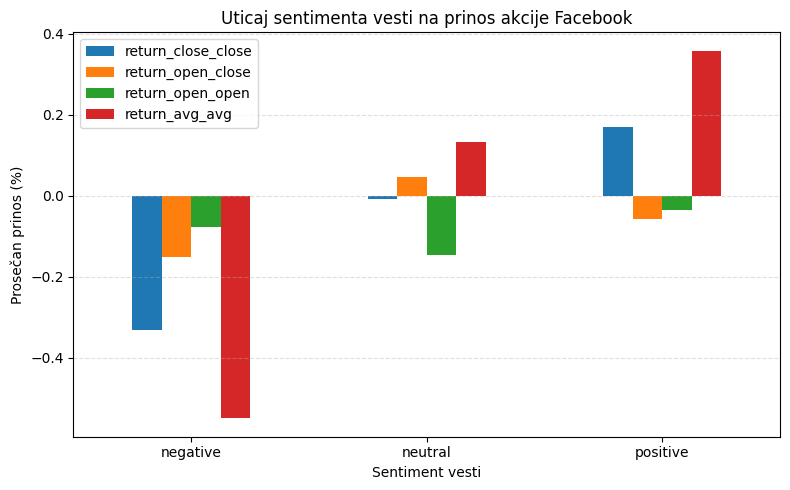

In [53]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Facebook")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

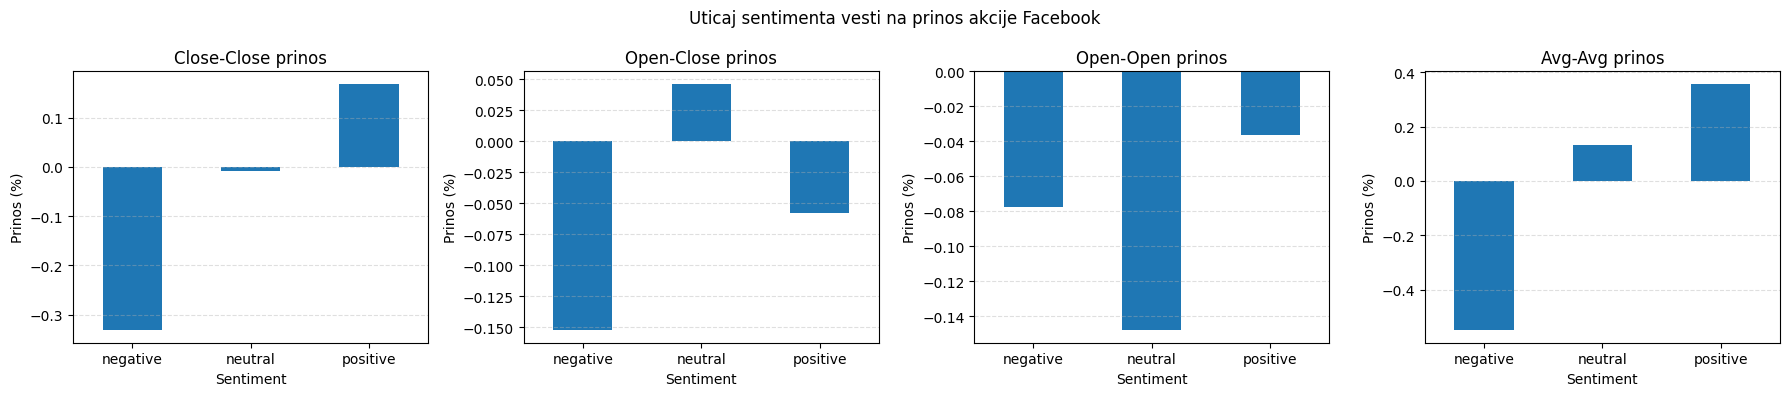

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Facebook")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

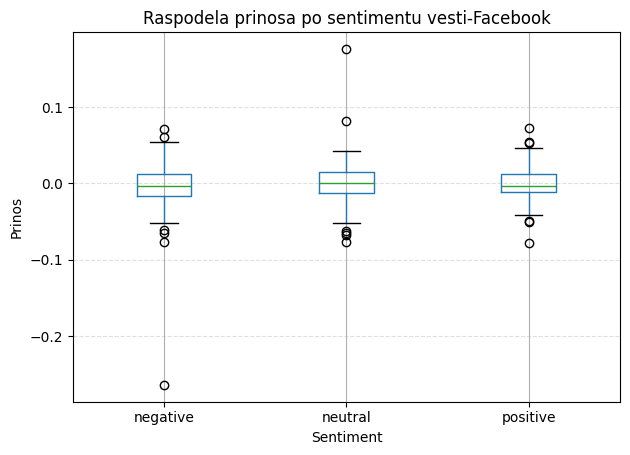

In [56]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti-Facebook")
plt.suptitle("")  # uklanja default naslov
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

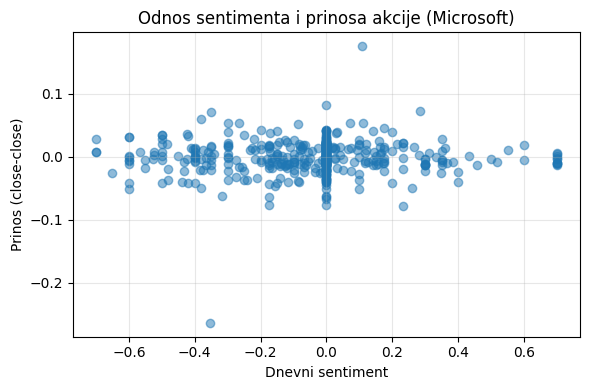

In [57]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Microsoft)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()